# Route B Experiment

**Flow:**
1. Load CLC data for 50 contracts
2. Fit GMM on **training period** → get soft probs `[p0, p1, p2]`
3. Apply GMM to **full period** → augment state: `9-dim + 3-dim = 12-dim`
4. Train A2C (`n_features=12`) on training period
5. Evaluate on test period
6. Compare metrics with original Route A (baseline 9-dim A2C)

**Periods:**
| Period | Train | Test |
|--------|-------|------|
| Period 1 | 2005-01-01 ~ 2010-12-31 | 2011-01-01 ~ 2015-12-31 |
| Period 2 | 2010-01-01 ~ 2015-12-31 | 2016-01-01 ~ 2019-12-31 |

## Section 0: Setup

In [6]:
import sys, os
from pathlib import Path

# Project root
PROJECT_ROOT = Path('/Users/ladymie/Documents/GitHub/IEOR4733_Project')
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'rl_models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import logging

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')
logger = logging.getLogger(__name__)

print('✅ Setup complete')

✅ Setup complete


## Section 1: Load CLC Data

In [7]:
from data_loader import load_clc_full
from config import ASSET_CLASSES

# All tickers
all_tickers = [t for tickers in ASSET_CLASSES.values() for t in tickers]

# Load with enough history for warmup (GMM needs 60+252 rows min)
DATA_START = '2004-01-01'

clc_data = {}
for ticker in all_tickers:
    try:
        df = load_clc_full(ticker, start_date=DATA_START)
        if df is not None:
            clc_data[ticker] = df
    except Exception as e:
        pass

print(f'✅ Loaded {len(clc_data)}/{len(all_tickers)} tickers')
for ac, tickers in ASSET_CLASSES.items():
    n = sum(1 for t in tickers if t in clc_data)
    print(f'  {ac}: {n}/{len(tickers)}')

✅ Loaded 50/50 tickers
  Commodity: 25/25
  Equity Index: 11/11
  Fixed Income: 5/5
  Forex: 9/9


## Section 2: Regime Detection (Fit GMM on Training Period)

This corresponds to the **Regime Detection** block in the flowchart:  
`Load Data → Build 60×9 matrix → FFT (180-dim) → GMM (n=3) → soft probs [p0,p1,p2]`

We fit one GMM **per asset class per period** using only training data.

In [8]:
from regime_detection.timeseries_fft_regime import (
    detect_regimes_for_asset_class_timeseries,
    predict_regime_soft_probs,
)

PERIODS = {
    'period_1': {
        'train': ('2005-01-01', '2010-12-31'),
        'test' : ('2011-01-01', '2015-12-31'),
    },
    'period_2': {
        'train': ('2010-01-01', '2015-12-31'),
        'test' : ('2016-01-01', '2019-12-31'),
    },
}

# Build 'All' class
ASSET_CLASSES_WITH_ALL = dict(ASSET_CLASSES)
ASSET_CLASSES_WITH_ALL['All'] = all_tickers

print('Asset classes:', list(ASSET_CLASSES_WITH_ALL.keys()))

Asset classes: ['Commodity', 'Equity Index', 'Fixed Income', 'Forex', 'All']


In [10]:
import pickle

CACHE_DIR = PROJECT_ROOT / 'regime_detection' / 'results'
CACHE_DIR.mkdir(exist_ok=True)
CACHE_PATH = CACHE_DIR / 'train_regime_results.pkl'

if CACHE_PATH.exists():
    with open(CACHE_PATH, 'rb') as f:
        train_regime_results = pickle.load(f)
    print(f'✅ Loaded GMM results from cache: {CACHE_PATH}')
    for period_name, ac_dict in train_regime_results.items():
        for asset_class, result in ac_dict.items():
            print(f'  {period_name} | {asset_class}: {result["n_time_points"]} time points | '
                  f'Silhouette={result["silhouette_score"]:.4f}')
else:
    # Fit GMM on training periods
    # Stores: train_regime_results[period_name][asset_class] = result dict
    train_regime_results = {}

    for period_name, cfg in PERIODS.items():
        train_start, train_end = cfg['train']
        print(f'\n{"="*60}')
        print(f'  {period_name}  Training period: {train_start} ~ {train_end}')
        print(f'{"="*60}')

        train_regime_results[period_name] = {}

        for asset_class, tickers in ASSET_CLASSES_WITH_ALL.items():
            result = detect_regimes_for_asset_class_timeseries(
                clc_data=clc_data,
                asset_class_tickers=tickers,
                asset_class_name=asset_class,
                n_regimes=3,
                date_range=(train_start, train_end),
            )
            if result is not None:
                train_regime_results[period_name][asset_class] = result
                print(f'  ✅ {asset_class}: {result["n_time_points"]} time points | '
                      f'Silhouette={result["silhouette_score"]:.4f}')

    # Save to cache
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(train_regime_results, f)
    print(f'\n✅ GMM fitting complete. Results cached to: {CACHE_PATH}')


INFO 
处理 Commodity (25 个资产)...
INFO   时间范围: 2005-01-01 ~ 2010-12-31
INFO   ✓ CC: 1507 个交易日
INFO   ✓ DA: 1507 个交易日
INFO   ✓ GI: 1510 个交易日
INFO   ✓ JO: 1507 个交易日
INFO   ✓ KC: 1507 个交易日
INFO   ✓ KW: 1511 个交易日
INFO   ✓ LB: 1511 个交易日
INFO   ✓ NR: 1511 个交易日
INFO   ✓ SB: 1507 个交易日
INFO   ✓ ZA: 1512 个交易日
INFO   ✓ ZC: 1512 个交易日
INFO   ✓ ZF: 1511 个交易日
INFO   ✓ ZG: 1512 个交易日
INFO   ✓ ZH: 1510 个交易日
INFO   ✓ ZI: 1512 个交易日
INFO   ✓ ZK: 1511 个交易日
INFO   ✓ ZL: 1512 个交易日
INFO   ✓ ZO: 1510 个交易日
INFO   ✓ ZP: 1512 个交易日
INFO   ✓ ZR: 1512 个交易日
INFO   ✓ ZT: 1511 个交易日
INFO   ✓ ZU: 1508 个交易日
INFO   ✓ ZW: 1512 个交易日
INFO   ✓ ZZ: 1511 个交易日
INFO   ✓ ZN: 1509 个交易日
INFO   ✓ 加载了 25 个有效资产
INFO   时间范围: 2005-01-03 至 2010-12-31 (1507 个交易日)
INFO   生成时间序列特征...



  period_1  Training period: 2005-01-01 ~ 2010-12-31


  Commodity: 100%|██████████| 1447/1447 [01:42<00:00, 14.14it/s]
INFO   ✓ 生成 1447 个时间点的特征 ((1447, 180))
INFO   执行GMM聚类 (n_clusters=3)...
INFO   ✓ 聚类完成
INFO     • 样本数: 1447
INFO     • Silhouette Score: 0.1890
INFO   📊 Regime分布:
INFO     Regime 0:   1028 ( 71.0%)
INFO     Regime 1:    335 ( 23.2%)
INFO     Regime 2:     84 (  5.8%)
INFO   ✅ Commodity 完成
INFO 
处理 Equity Index (11 个资产)...
INFO   时间范围: 2005-01-01 ~ 2010-12-31
INFO   ✓ CA: 1535 个交易日
INFO   ✓ EN: 1512 个交易日
INFO   ✓ ER: 1513 个交易日
INFO   ✓ ES: 1513 个交易日
INFO   ✓ LX: 1521 个交易日
INFO   ✓ MD: 1511 个交易日
INFO   ✓ SC: 1512 个交易日
INFO   ✓ SP: 1511 个交易日
INFO   ✓ XU: 1528 个交易日
INFO   ✓ XX: 1528 个交易日
INFO   ✓ YM: 1513 个交易日
INFO   ✓ 加载了 11 个有效资产
INFO   时间范围: 2005-02-04 至 2010-12-31 (1511 个交易日)
INFO   生成时间序列特征...


  ✅ Commodity: 1447 time points | Silhouette=0.1890


  Equity Index: 100%|██████████| 1451/1451 [00:46<00:00, 31.21it/s]
INFO   ✓ 生成 1451 个时间点的特征 ((1451, 180))
INFO   执行GMM聚类 (n_clusters=3)...
INFO   ✓ 聚类完成
INFO     • 样本数: 1451
INFO     • Silhouette Score: 0.1010
INFO   📊 Regime分布:
INFO     Regime 0:    759 ( 52.3%)
INFO     Regime 1:    342 ( 23.6%)
INFO     Regime 2:    350 ( 24.1%)
INFO   ✅ Equity Index 完成
INFO 
处理 Fixed Income (5 个资产)...
INFO   时间范围: 2005-01-01 ~ 2010-12-31
INFO   ✓ DT: 1528 个交易日
INFO   ✓ FB: 1510 个交易日
INFO   ✓ TY: 1510 个交易日
INFO   ✓ UB: 1528 个交易日
INFO   ✓ US: 1510 个交易日
INFO   ✓ 加载了 5 个有效资产
INFO   时间范围: 2005-01-27 至 2010-12-30 (1510 个交易日)
INFO   生成时间序列特征...


...

  ✅ Fixed Income: 1455 time points | Silhouette=0.0190


  Forex: 100%|██████████| 1448/1448 [00:38<00:00, 37.80it/s]
INFO   ✓ 生成 1448 个时间点的特征 ((1448, 180))
INFO   执行GMM聚类 (n_clusters=3)...
INFO   ✓ 聚类完成
INFO     • 样本数: 1448
INFO     • Silhouette Score: 0.1018
INFO   📊 Regime分布:
INFO     Regime 0:    345 ( 23.8%)
INFO     Regime 1:    249 ( 17.2%)
INFO     Regime 2:    854 ( 59.0%)
INFO   ✅ Forex 完成
INFO 
处理 All (50 个资产)...
INFO   时间范围: 2010-01-01 ~ 2015-12-31
INFO   ✓ CC: 1511 个交易日
INFO   ✓ DA: 1510 个交易日
INFO   ✓ GI: 1512 个交易日
INFO   ✓ JO: 1512 个交易日
INFO   ✓ KC: 1511 个交易日
INFO   ✓ KW: 1512 个交易日
INFO   ✓ LB: 1509 个交易日
INFO   ✓ NR: 1512 个交易日
INFO   ✓ SB: 1511 个交易日
INFO   ✓ ZA: 1512 个交易日
INFO   ✓ ZC: 1512 个交易日
INFO   ✓ ZF: 1512 个交易日
INFO   ✓ ZG: 1512 个交易日
INFO   ✓ ZH: 1512 个交易日
INFO   ✓ ZI: 1512 个交易日
INFO   ✓ ZK: 1512 个交易日
INFO   ✓ ZL: 1512 个交易日
INFO   ✓ ZO: 1512 个交易日
INFO   ✓ ZP: 1512 个交易日
INFO   ✓ ZR: 1512 个交易日
INFO   ✓ ZT: 1512 个交易日
INFO   ✓ ZU: 1512 个交易日
INFO   ✓ ZW: 1512 个交易日
INFO   ✓ ZZ: 1512 个交易日
INFO   ✓ ZN: 1512 个交易日
INFO   ✓ CA: 1533

  ✅ Forex: 1448 time points | Silhouette=0.1018


  All: 100%|██████████| 1448/1448 [03:25<00:00,  7.04it/s]
INFO   ✓ 生成 1448 个时间点的特征 ((1448, 180))
INFO   执行GMM聚类 (n_clusters=3)...
INFO   ✓ 聚类完成
INFO     • 样本数: 1448
INFO     • Silhouette Score: 0.1240
INFO   📊 Regime分布:
INFO     Regime 0:    492 ( 34.0%)
INFO     Regime 1:    484 ( 33.4%)
INFO     Regime 2:    472 ( 32.6%)
INFO   ✅ All 完成


  ✅ All: 1448 time points | Silhouette=0.1240

✅ GMM fitting complete. Results cached to: /Users/ladymie/Documents/GitHub/IEOR4733_Project/regime_detection/results/train_regime_results.pkl


## Section 4: Predict Soft Probs for Full Period (Train + Test)

Apply the trained GMM to the combined train+test window to get soft probs  
for every trading day, so we can augment the A2C state during both training and test.

In [11]:
FULL_CACHE_PATH = CACHE_DIR / 'full_regime_dfs.pkl'

FULL_RANGES = {
    'period_1': (DATA_START, '2015-12-31'),
    'period_2': (DATA_START, '2019-12-31'),
}

if FULL_CACHE_PATH.exists():
    with open(FULL_CACHE_PATH, 'rb') as f:
        full_regime_dfs = pickle.load(f)
    print(f'✅ Loaded full-period regime DFs from cache: {FULL_CACHE_PATH}')
    for period_name, ac_dict in full_regime_dfs.items():
        for asset_class, regime_df in ac_dict.items():
            print(f'  {period_name} | {asset_class}: {len(regime_df)} time points')
else:
    # full_regime_dfs[period_name][asset_class] = DataFrame(date, regime, p0, p1, p2)
    full_regime_dfs = {}

    for period_name, cfg in PERIODS.items():
        full_start, full_end = FULL_RANGES[period_name]
        print(f'\n{period_name} full range: {full_start} ~ {full_end}')

        full_regime_dfs[period_name] = {}

        for asset_class, tickers in ASSET_CLASSES_WITH_ALL.items():
            if asset_class not in train_regime_results[period_name]:
                continue

            trained_result = train_regime_results[period_name][asset_class]

            regime_df = predict_regime_soft_probs(
                clc_data=clc_data,
                asset_class_tickers=tickers,
                asset_class_name=asset_class,
                trained_gmm=trained_result['gmm_model'],
                trained_scaler=trained_result['fft_scaler'],
                date_range=(full_start, full_end),
            )

            if regime_df is not None:
                full_regime_dfs[period_name][asset_class] = regime_df
                print(f'  ✅ {asset_class}: {len(regime_df)} time points')
            else:
                print(f'  ❌ {asset_class}: failed')

    # Save to cache
    with open(FULL_CACHE_PATH, 'wb') as f:
        pickle.dump(full_regime_dfs, f)
    print(f'\n✅ Full-period soft probs ready. Cached to: {FULL_CACHE_PATH}')


INFO 
[predict] Commodity soft-prob prediction...
INFO   date_range: 2004-01-01 ~ 2015-12-31
INFO   time range: 2004-01-06 ~ 2015-12-31 (3014 days)



period_1 full range: 2004-01-01 ~ 2015-12-31


  Commodity (predict): 100%|██████████| 2954/2954 [03:20<00:00, 14.73it/s]
INFO   ✓ Commodity: 2954 time points predicted
INFO 
[predict] Equity Index soft-prob prediction...
INFO   date_range: 2004-01-01 ~ 2015-12-31
INFO   time range: 2004-03-08 ~ 2015-12-31 (3024 days)


  ✅ Commodity: 2954 time points


  Equity Index (predict): 100%|██████████| 2964/2964 [01:30<00:00, 32.92it/s]
INFO   ✓ Equity Index: 2964 time points predicted
INFO 
[predict] Fixed Income soft-prob prediction...
INFO   date_range: 2004-01-01 ~ 2015-12-31
INFO   time range: 2004-02-16 ~ 2015-12-30 (3022 days)


...

  ✅ Fixed Income: 3968 time points


  Forex (predict): 100%|██████████| 3961/3961 [01:36<00:00, 40.92it/s]
INFO   ✓ Forex: 3961 time points predicted
INFO 
[predict] All soft-prob prediction...
INFO   date_range: 2004-01-01 ~ 2019-12-31
INFO   time range: 2004-01-08 ~ 2019-12-31 (4019 days)


  ✅ Forex: 3961 time points


  All (predict): 100%|██████████| 3959/3959 [08:52<00:00,  7.44it/s]
INFO   ✓ All: 3959 time points predicted


  ✅ All: 3959 time points

✅ Full-period soft probs ready. Cached to: /Users/ladymie/Documents/GitHub/IEOR4733_Project/regime_detection/results/full_regime_dfs.pkl


## Section 5: Build 12-dim Augmented State & Train A2C

State = `[close_norm, ret_1m, ret_2m, ret_3m, ret_1y, macd_8_24, macd_16_48, macd_32_96, rsi_30]`  
+ `[regime_prob_0, regime_prob_1, regime_prob_2]`  
= **12-dim** input per time step in the 60-step LSTM window.

In [20]:
from regime_detection.route_b_train import (
    run_route_b,
    _load_rad_data_for_a2c,
    _build_augmented_state_dict,
    FEATURE_COLS_12,
    SIGMA_TARGET,
)
from rl_models.a2c_model import PaperA2CTrainer, build_envs_from_state_dict, DEVICE

print('FEATURE_COLS_12:', FEATURE_COLS_12)
print('SIGMA_TARGET (daily):', f'{SIGMA_TARGET:.6f}  (~{SIGMA_TARGET*np.sqrt(252)*100:.1f}% annual)')
print('Device:', DEVICE)

FEATURE_COLS_12: ['close_norm', 'ret_1m', 'ret_2m', 'ret_3m', 'ret_1y', 'macd_8_24', 'macd_16_48', 'macd_32_96', 'rsi_30', 'regime_prob_0', 'regime_prob_1', 'regime_prob_2']
SIGMA_TARGET (daily): 0.009449  (~15.0% annual)
Device: cpu


In [21]:
# ── Choose what to train ──────────────────────────────────────────────────────
# Set QUICK_TEST=True for a fast sanity check (100 updates, single asset class)
# Set QUICK_TEST=False to run all classes and both periods

QUICK_TEST    = False
N_UPDATES     = 100   if QUICK_TEST else 2000
TARGET_CLASSES = ['All'] if QUICK_TEST else list(ASSET_CLASSES_WITH_ALL.keys())
TARGET_PERIODS = ['period_1'] if QUICK_TEST else ['period_1', 'period_2']

print(f'QUICK_TEST={QUICK_TEST}  N_UPDATES={N_UPDATES}')
print(f'Classes: {TARGET_CLASSES}')
print(f'Periods: {TARGET_PERIODS}')

QUICK_TEST=False  N_UPDATES=2000
Classes: ['Commodity', 'Equity Index', 'Fixed Income', 'Forex', 'All']
Periods: ['period_1', 'period_2']


In [22]:
# Train Route B models (skip if checkpoint already exists)
# Results stored in route_b_results[period_name][asset_class]

route_b_results = {}

for period_name in TARGET_PERIODS:
    route_b_results[period_name] = {}
    cfg = PERIODS[period_name]
    train_start, train_end = cfg['train']
    test_start,  test_end  = cfg['test']

    for asset_class in TARGET_CLASSES:
        tickers = ASSET_CLASSES_WITH_ALL[asset_class]

        if asset_class not in full_regime_dfs.get(period_name, {}):
            print(f'⚠️  No regime data for {asset_class} {period_name}, skipping')
            continue

        ckpt_path = str(
            PROJECT_ROOT / 'rl_models' /
            f'a2c_rb_{asset_class.replace(" ", "_")}_{period_name}.pt'
        )

        # Build 12-dim augmented state (always needed for test_sd)
        feature_dict = _load_rad_data_for_a2c(tickers, DATA_START, test_end)
        regime_df = full_regime_dfs[period_name][asset_class]
        train_sd, test_sd = _build_augmented_state_dict(
            feature_dict=feature_dict,
            regime_df=regime_df,
            train_start=train_start, train_end=train_end,
            test_start=test_start,   test_end=test_end,
        )

        if Path(ckpt_path).exists():
            # Load existing checkpoint, skip training
            trainer = PaperA2CTrainer(n_features=12, device=DEVICE)
            trainer.load_checkpoint(ckpt_path)
            print(f'✅ Loaded existing checkpoint: {Path(ckpt_path).name}  '
                  f'({period_name} | {asset_class})')
        else:
            print(f'\n{"="*60}')
            print(f'Training Route B: {asset_class} | {period_name}')
            print(f'{"="*60}')
            print(f'  Train tickers: {len(train_sd)}  |  Test tickers: {len(test_sd)}')

            if not train_sd:
                print('  ❌ No training states')
                continue

            train_envs = build_envs_from_state_dict(
                state_dict=train_sd,
                tickers=list(train_sd.keys()),
                sigma_target=SIGMA_TARGET,
            )
            print(f'  Training envs: {len(train_envs)}')

            trainer = PaperA2CTrainer(n_features=12, device=DEVICE)
            trainer.fit(
                envs=train_envs,
                n_updates=N_UPDATES,
                rollout_steps=32,
                log_every=max(1, N_UPDATES // 10),
                checkpoint_path=ckpt_path,
                checkpoint_every=max(1, N_UPDATES // 5),
            )
            trainer.save_checkpoint(ckpt_path)
            print(f'  ✅ Checkpoint saved: {Path(ckpt_path).name}')

        route_b_results[period_name][asset_class] = {
            'trainer': trainer,
            'test_sd': test_sd,
            'checkpoint': ckpt_path,
        }

print('\n✅ Training complete')


✅ Loaded existing checkpoint: a2c_rb_Commodity_period_1.pt  (period_1 | Commodity)
✅ Loaded existing checkpoint: a2c_rb_Equity_Index_period_1.pt  (period_1 | Equity Index)
✅ Loaded existing checkpoint: a2c_rb_Fixed_Income_period_1.pt  (period_1 | Fixed Income)
✅ Loaded existing checkpoint: a2c_rb_Forex_period_1.pt  (period_1 | Forex)
✅ Loaded existing checkpoint: a2c_rb_All_period_1.pt  (period_1 | All)
✅ Loaded existing checkpoint: a2c_rb_Commodity_period_2.pt  (period_2 | Commodity)
✅ Loaded existing checkpoint: a2c_rb_Equity_Index_period_2.pt  (period_2 | Equity Index)
✅ Loaded existing checkpoint: a2c_rb_Fixed_Income_period_2.pt  (period_2 | Fixed Income)
✅ Loaded existing checkpoint: a2c_rb_Forex_period_2.pt  (period_2 | Forex)
✅ Loaded existing checkpoint: a2c_rb_All_period_2.pt  (period_2 | All)

✅ Training complete


## Section 6: Evaluate on Test Period

In [24]:
import importlib
import regime_detection.route_b_train as _rb_module
importlib.reload(_rb_module)
from regime_detection.route_b_train import _evaluate

PNL_SAVE_DIR = PROJECT_ROOT / 'regime_detection' / 'results'
PNL_SAVE_DIR.mkdir(exist_ok=True)

eval_results = {}

for period_name, ac_dict in route_b_results.items():
    eval_results[period_name] = {}
    for asset_class, obj in ac_dict.items():
        metrics = _evaluate(
            actor=obj['trainer'].actor,
            test_state_dict=obj['test_sd'],
            sigma_target=SIGMA_TARGET,
        )
        eval_results[period_name][asset_class] = metrics
        print(
            f'{period_name} | {asset_class:<16} '
            f'Sharpe={metrics.get("portfolio_sharpe", float("nan")):.3f}  '
            f'Calmar={metrics.get("portfolio_calmar", float("nan")):.3f}  '
            f'AnnRet={metrics.get("portfolio_ann_ret", float("nan")):.4f}'
        )

        # Save daily PnL CSV for use in strategies_comparison.ipynb
        portfolio_pnl = metrics.get('portfolio_pnl')
        if portfolio_pnl is not None and len(portfolio_pnl) > 0:
            ac_slug = asset_class.replace(' ', '_')
            csv_path = PNL_SAVE_DIR / f'pnl_routeB_{period_name}_{ac_slug}.csv'
            pnl_df = pd.DataFrame({
                'date':      portfolio_pnl.index,
                'net_pnl':   portfolio_pnl.values,
                'cum_wealth': 1.0 + portfolio_pnl.cumsum().values,
            })
            pnl_df.to_csv(csv_path, index=False)
            print(f'  💾 Saved: {csv_path.name}  ({len(pnl_df)} rows)')
        else:
            print(f'  ⚠️  portfolio_pnl is None for {asset_class} {period_name}')

print(f'\n✅ Evaluation complete. PnL CSVs saved to: {PNL_SAVE_DIR}')


period_1 | Commodity        Sharpe=-0.958  Calmar=-0.186  AnnRet=-0.0448
  💾 Saved: pnl_routeB_period_1_Commodity.csv  (1199 rows)
period_1 | Equity Index     Sharpe=0.458  Calmar=0.324  AnnRet=0.0457
  💾 Saved: pnl_routeB_period_1_Equity_Index.csv  (1229 rows)
period_1 | Fixed Income     Sharpe=0.770  Calmar=0.451  AnnRet=0.0818
  💾 Saved: pnl_routeB_period_1_Fixed_Income.csv  (1228 rows)
period_1 | Forex            Sharpe=-0.693  Calmar=-0.160  AnnRet=-0.0376
  💾 Saved: pnl_routeB_period_1_Forex.csv  (1232 rows)
period_1 | All              Sharpe=-0.294  Calmar=-0.073  AnnRet=-0.0026
  💾 Saved: pnl_routeB_period_1_All.csv  (1232 rows)
period_2 | Commodity        Sharpe=-0.284  Calmar=-0.172  AnnRet=-0.0114
  💾 Saved: pnl_routeB_period_2_Commodity.csv  (946 rows)
period_2 | Equity Index     Sharpe=0.893  Calmar=0.453  AnnRet=0.0804
  💾 Saved: pnl_routeB_period_2_Equity_Index.csv  (971 rows)
period_2 | Fixed Income     Sharpe=0.112  Calmar=0.050  AnnRet=0.0119
  💾 Saved: pnl_routeB_per

## Section 8: Training Loss Curve

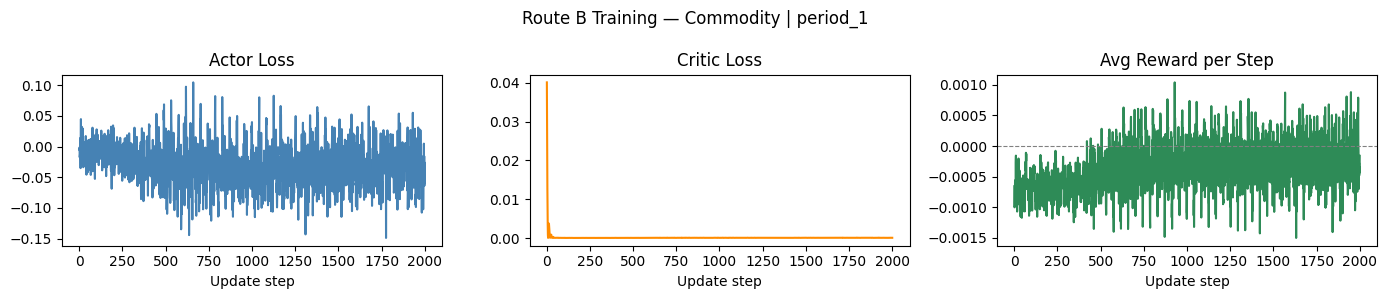

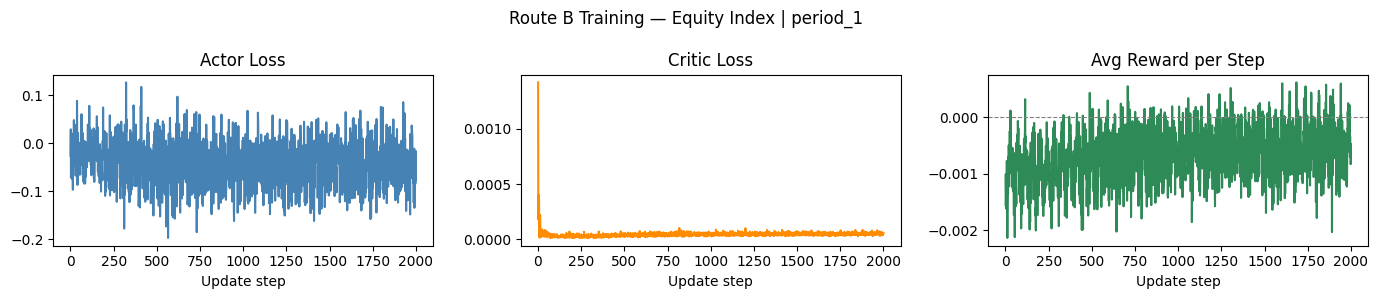

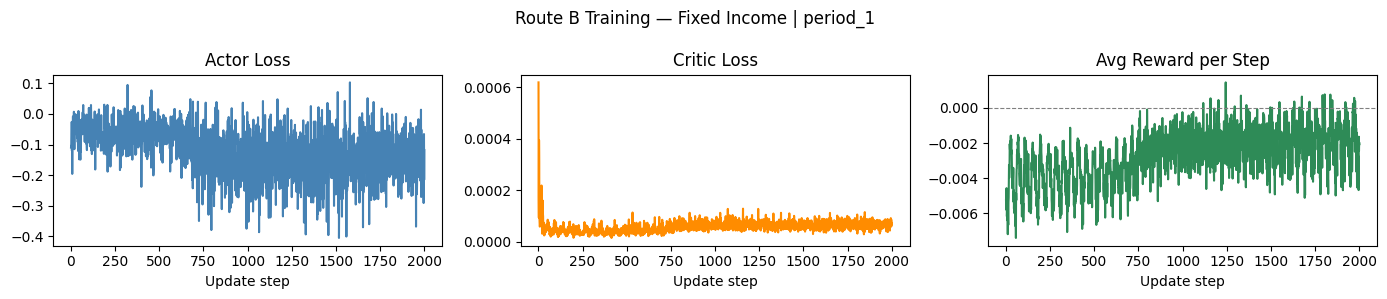

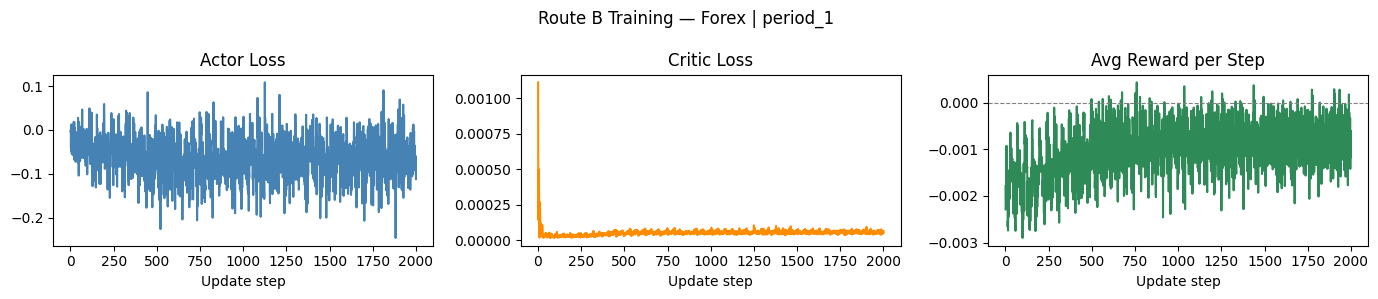

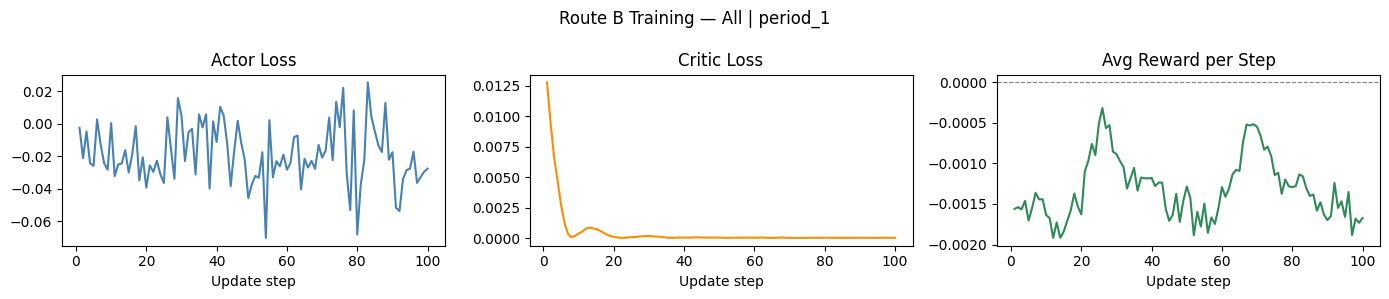

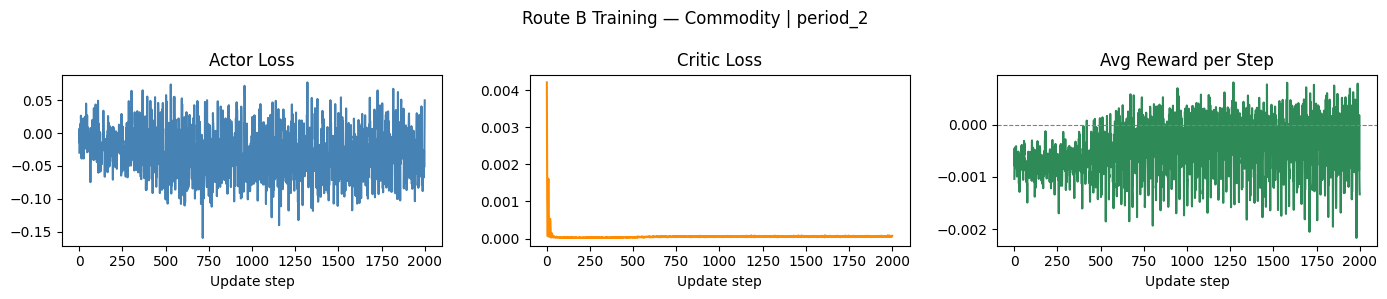

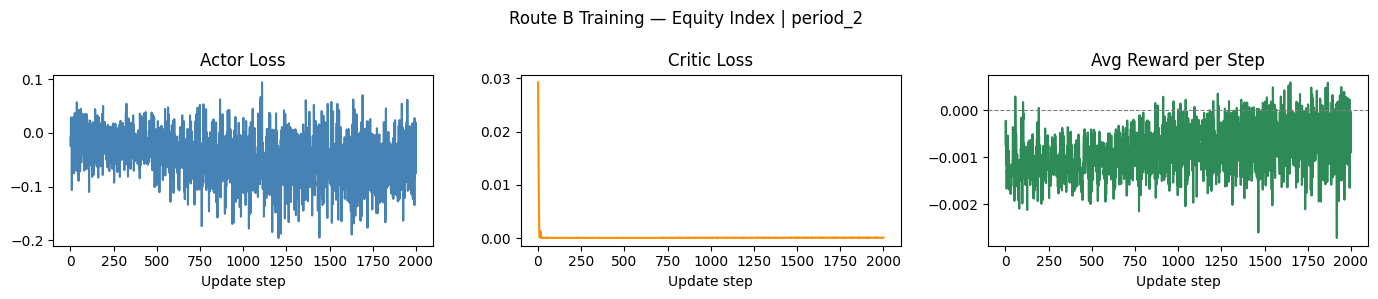

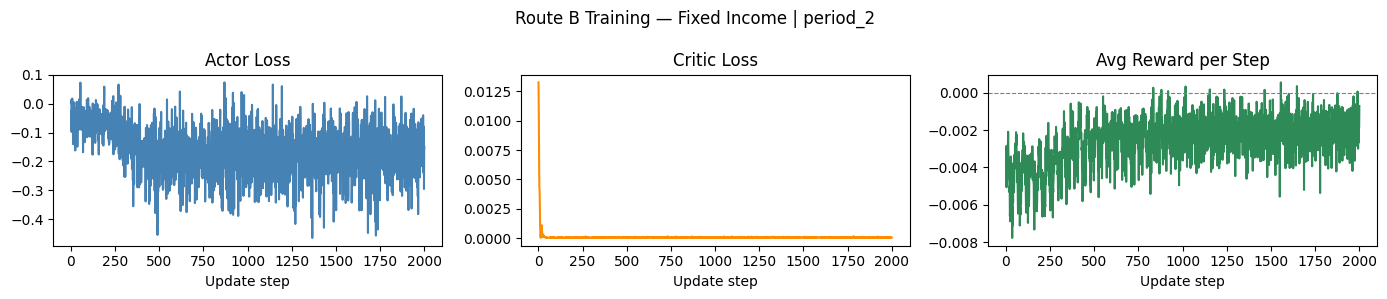

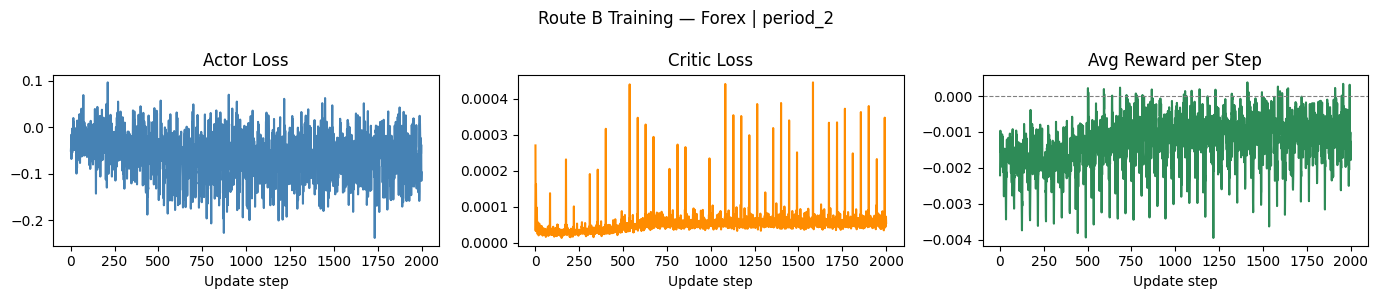

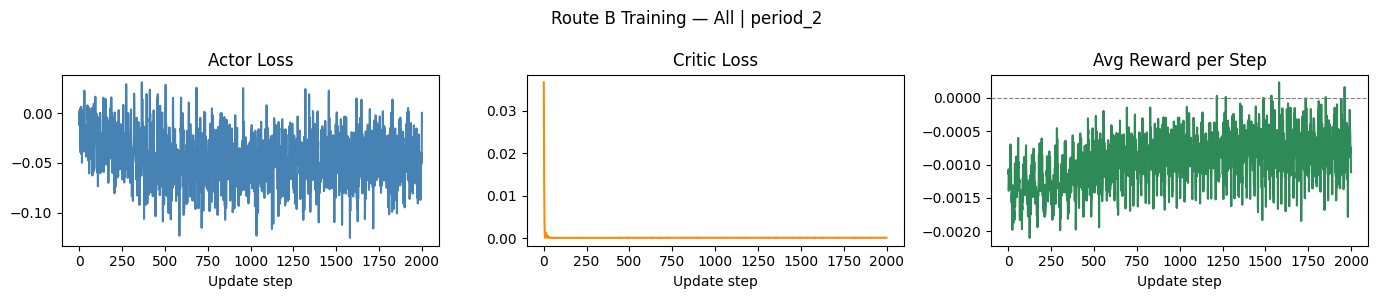

In [17]:
# Plot actor/critic loss for Route B training
for period_name, ac_dict in route_b_results.items():
    for asset_class, obj in ac_dict.items():
        log = obj['trainer'].train_log
        if not log:
            continue

        steps        = list(range(1, len(log) + 1))
        actor_losses = [x['actor_loss'] for x in log]
        critic_losses= [x['critic_loss'] for x in log]
        avg_rewards  = [x['avg_reward'] for x in log]

        fig, axes = plt.subplots(1, 3, figsize=(14, 3))
        axes[0].plot(steps, actor_losses,  color='steelblue')
        axes[0].set_title('Actor Loss')
        axes[0].set_xlabel('Update step')

        axes[1].plot(steps, critic_losses, color='darkorange')
        axes[1].set_title('Critic Loss')
        axes[1].set_xlabel('Update step')

        axes[2].plot(steps, avg_rewards,   color='seagreen')
        axes[2].set_title('Avg Reward per Step')
        axes[2].set_xlabel('Update step')
        axes[2].axhline(0, color='gray', linewidth=0.8, linestyle='--')

        fig.suptitle(f'Route B Training — {asset_class} | {period_name}', fontsize=12)
        plt.tight_layout()
        plt.show()

## Section 9: Save Full-Period Regime CSVs for Reuse

In [18]:
# Save the full-period soft prob CSVs to regime_detection/results/
results_dir = PROJECT_ROOT / 'regime_detection' / 'results'
results_dir.mkdir(exist_ok=True)

for period_name, ac_dict in full_regime_dfs.items():
    for asset_class, regime_df in ac_dict.items():
        fname = f'regime_routeB_{period_name}_{asset_class.replace(" ", "_")}.csv'
        fpath = results_dir / fname
        regime_df.to_csv(fpath, index=False)
        print(f'  Saved {fname}  ({len(regime_df)} rows)')

print(f'\n✅ All CSVs saved to {results_dir}')

  Saved regime_routeB_period_1_Commodity.csv  (2954 rows)
  Saved regime_routeB_period_1_Equity_Index.csv  (2964 rows)
  Saved regime_routeB_period_1_Fixed_Income.csv  (2962 rows)
  Saved regime_routeB_period_1_Forex.csv  (2954 rows)
  Saved regime_routeB_period_1_All.csv  (2954 rows)
  Saved regime_routeB_period_2_Commodity.csv  (3959 rows)
  Saved regime_routeB_period_2_Equity_Index.csv  (3962 rows)
  Saved regime_routeB_period_2_Fixed_Income.csv  (3968 rows)
  Saved regime_routeB_period_2_Forex.csv  (3961 rows)
  Saved regime_routeB_period_2_All.csv  (3959 rows)

✅ All CSVs saved to /Users/ladymie/Documents/GitHub/IEOR4733_Project/regime_detection/results
